In [1]:
import torch
import pickle
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split

In [35]:
#defining Model
class Model(nn.Module):

    def __init__(self):
      super().__init__()

      self.firstBranch=nn.Sequential(
          nn.Linear(784,16),
          nn.ReLU()
      )

      self.branch1=nn.Sequential(
          nn.Linear(16,12),
          nn.ReLU(),
          nn.Linear(12,8),
          nn.ReLU()
      )

      self.branch2=nn.Sequential(
          nn.Linear(16,8),
          nn.ReLU(),
          nn.Linear(8,8),
          nn.ReLU()
      )

      self.output=nn.Linear(16,10)

    
    def forward(self,x):
      #flattening step
      x = x.view(x.shape[0],-1)
      
      x1=self.firstBranch(x)
      x2=self.branch1(x1)
      x3=self.branch2(x1)
      
      merged=torch.cat((x2,x3),dim=1)

      logits=self.output(merged)

      return logits

In [36]:
#Loading Datasets

train = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

train_size = int(0.8*(len(train)))
val_size = int(len(train)-train_size)

#splitting dataset for train and validation
train_dataset, val_dataset = random_split(train, [train_size, val_size])

In [37]:
#now we want load datasets via dataloader

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)

In [38]:
model = Model()

In [39]:
epochs=20

loss_history=[]
accuracy_history=[]

crieterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for _ in range(epochs):
    count=0
    total=0
    
    for img, labels in train_dataloader:
        optimizer.zero_grad()
    
        output = model(img)
    
        loss = crieterion(output, labels)
        loss_history.append(loss.item())

        _,pred=torch.max(output,1)
        count+=(pred==labels).sum().item()
        total+=labels.size(0)
    
        loss.backward()
    
        optimizer.step()
    
        #accuracy 
        accuracy=count/total
        accuracy_history.append(accuracy)
    

In [40]:
loss_history

[2.3202455043792725,
 2.3175675868988037,
 2.2985050678253174,
 2.2919464111328125,
 2.28578519821167,
 2.3163557052612305,
 2.291646718978882,
 2.2809510231018066,
 2.2993109226226807,
 2.284214973449707,
 2.2736968994140625,
 2.2840375900268555,
 2.2726240158081055,
 2.2481679916381836,
 2.222433090209961,
 2.2455637454986572,
 2.2366156578063965,
 2.2294862270355225,
 2.2081384658813477,
 2.2076282501220703,
 2.2083702087402344,
 2.180600643157959,
 2.173889398574829,
 2.174668073654175,
 2.1392264366149902,
 2.1439764499664307,
 2.138028383255005,
 2.1200077533721924,
 2.116364002227783,
 2.1243550777435303,
 2.0691559314727783,
 2.0553438663482666,
 2.043212652206421,
 2.0761008262634277,
 2.053825855255127,
 1.973751187324524,
 2.091165781021118,
 1.9640626907348633,
 2.0133872032165527,
 2.0308570861816406,
 1.9589718580245972,
 1.9939548969268799,
 1.9269942045211792,
 1.9412426948547363,
 1.8529233932495117,
 1.8644040822982788,
 1.8620997667312622,
 1.8466742038726807,
 1.823

In [41]:
accuracy

0.872625

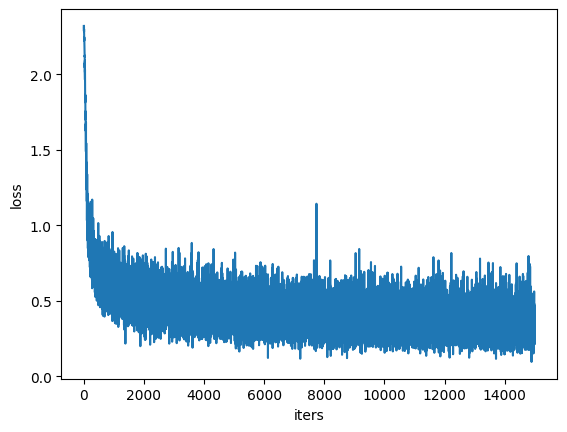

In [42]:
plt.plot(loss_history)
plt.xlabel("iters")
plt.ylabel("loss")
plt.show()

In [43]:
with open("fashion_model.pkl", "wb") as f:
    pickle.dump(model.state_dict(),f)
    

In [44]:
with open("fashion_model.pkl", "rb") as f:
    weights = pickle.load(f)

model.load_state_dict(weights)

<All keys matched successfully>

<function matplotlib.pyplot.show(close=None, block=None)>

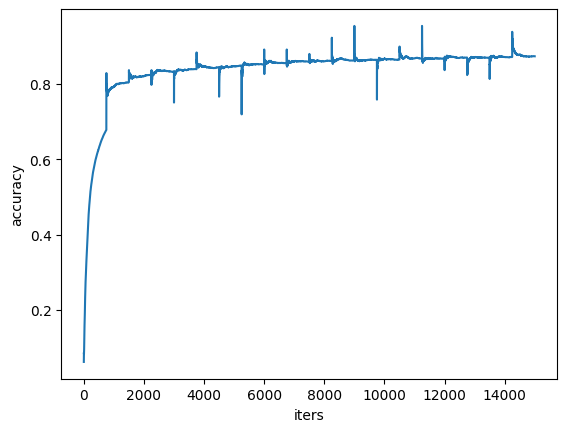

In [45]:
plt.plot(accuracy_history)
plt.xlabel("iters")
plt.ylabel("accuracy")
plt.show